# **!!_14_Testing on the Concrete Strength dataset + Time**

# **Ksi = 0**

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 58.0/58.0 kB 744.7 kB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 396.0/396.0 kB 4.0 MB/s eta 0:00:00
CONCRETE STRENGTH DATASET - OUTLIER DETECTION COMPARISON (WITH TIMING)
Program started at: 2026-05-25 02:18:33

CREATING 'CONCRETE STRENGTH' DATASET WITH OUTLIERS
Dataset loading time: 2.12 seconds
Original dataset loaded.
Size: 1030 rows, 9 columns
Strength range: 2.33 – 82.60 MPa

STEP 1: FIND MAXIMUM, MINIMUM AND AVERAGE STRENGTH VALUES:
Maximum strength (Smax): 82.60 MPa
Minimum strength (Smin): 2.33 MPa
Average strength (Savg): 42.47 MPa

STEP 2: SORT DATASET IN DESCENDING ORDER BY STRENGTH
Sorted dataset created (descending order).

STEPS 3 & 4: REPLACE STRENGTH VALUES WITH AVERAGE (CREATING 20 OUTLIERS)
  • First 10 observations (highest strength): replaced with Savg (42.47 MPa)
  • Last 10 observations (lowest strength): replaced with Savg (42.47 MPa)

🔴 REPLACING FIRST 10 OBSERVATIONS (HIGHEST STRENGTH) WITH AVERAGE:



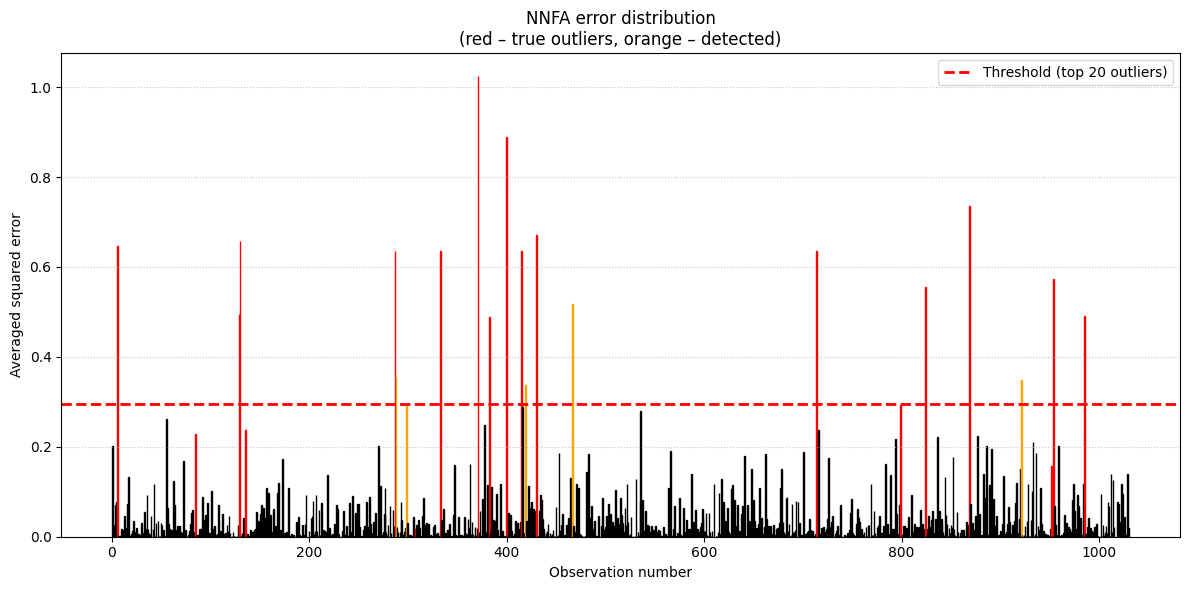


PROGRAM EXECUTION TIMING SUMMARY
Program started:  2026-05-25 02:18:33
Program ended:    2026-05-25 02:18:54
Total runtime:    21.10 seconds (0.35 minutes)

CONCLUSIONS:
✓ Outliers created by replacing extreme values with average value (42.47 MPa)
  - Type H→A: 10 observations (were the highest strength, became average)
  - Type L→A: 10 observations (were the lowest strength, became average)
✓ Total outliers: 20 (1.942% of data)
✓ ALL methods return exactly 20 outliers (top-K approach)
✓ These are structural outliers that violate the relationship between features and target
✓ NNFA successfully detects outliers because it models the relationship y = f(X)
✓ Methods using prediction error can also detect outliers
✓ PyOD methods (input features only) DO NOT detect structural outliers

📊 Fastest method: Combined (RF+AE) (0.00s)
📊 Slowest method: NNFA (6.18s)

TESTING COMPLETED.


In [ ]:
# *******************************************************
#      Concrete_Strength_(1%_Outliers) with Timing
# *******************************************************
import sys
!{sys.executable} -m pip install pyod

import time
import numpy as np
import pandas as pd
import math
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import precision_score, recall_score, f1_score
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

# PyOD detectors (work only with input features)
from pyod.models import abod, hbos, iforest, knn, lof, ocsvm, pca, copod

# Detectors that can take the target variable into account
from sklearn.ensemble import IsolationForest as SklearnIForest
from sklearn.svm import OneClassSVM
from sklearn.covariance import EllipticEnvelope
from sklearn.neighbors import LocalOutlierFactor
from sklearn.ensemble import RandomForestRegressor
from sklearn.neural_network import MLPRegressor

# Autoencoder for outlier detection (PyTorch)
import torch.nn.functional as F

# ==========================================================
# START TIMER FOR ENTIRE PROGRAM
# ==========================================================
program_start_time = time.time()
program_start_str = time.strftime("%Y-%m-%d %H:%M:%S", time.localtime(program_start_time))

print("="*80)
print("CONCRETE STRENGTH DATASET - OUTLIER DETECTION COMPARISON (WITH TIMING)")
print("="*80)
print(f"Program started at: {program_start_str}\n")

# ==========================================================
# PART 1: CREATING THE "CONCRETE STRENGTH" DATASET WITH OUTLIERS
# ==========================================================
print("="*60)
print("CREATING 'CONCRETE STRENGTH' DATASET WITH OUTLIERS")
print("="*60)

# Loading the original dataset from UCI Machine Learning Repository
start_load = time.time()
url = "https://archive.ics.uci.edu/ml/machine-learning-databases/concrete/compressive/Concrete_Data.xls"
df = pd.read_excel(url)
load_time = time.time() - start_load
print(f"Dataset loading time: {load_time:.2f} seconds")

# Assigning meaningful column names
df.columns = [
    'Cement', 'BlastFurnaceSlag', 'FlyAsh', 'Water',
    'Superplasticizer', 'CoarseAggregate', 'FineAggregate',
    'Age', 'CompressiveStrength'
]

print("Original dataset loaded.")
print(f"Size: {df.shape[0]} rows, {df.shape[1]} columns")
print(f"Strength range: {df['CompressiveStrength'].min():.2f} – {df['CompressiveStrength'].max():.2f} MPa\n")

# Step 1: Find maximum and minimum strength values
Smax = df['CompressiveStrength'].max()
Smin = df['CompressiveStrength'].min()

# Calculate average value
Savg = (Smax + Smin) / 2

print("="*60)
print("STEP 1: FIND MAXIMUM, MINIMUM AND AVERAGE STRENGTH VALUES:")
print("="*60)
print(f"Maximum strength (Smax): {Smax:.2f} MPa")
print(f"Minimum strength (Smin): {Smin:.2f} MPa")
print(f"Average strength (Savg): {Savg:.2f} MPa\n")

# Step 2: Sort dataset in descending order by CompressiveStrength
df_sorted = df.sort_values('CompressiveStrength', ascending=False).reset_index(drop=True)

print("="*60)
print("STEP 2: SORT DATASET IN DESCENDING ORDER BY STRENGTH")
print("="*60)
print(f"Sorted dataset created (descending order).\n")

# Steps 3 & 4: Replace values with average (Savg) for 20 outliers (10 highest + 10 lowest)
n_outliers_per_group = 10
total_outliers = n_outliers_per_group * 2  # = 20
print("="*60)
print(f"STEPS 3 & 4: REPLACE STRENGTH VALUES WITH AVERAGE (CREATING {total_outliers} OUTLIERS)")
print("="*60)
print(f"  • First {n_outliers_per_group} observations (highest strength): replaced with Savg ({Savg:.2f} MPa)")
print(f"  • Last {n_outliers_per_group} observations (lowest strength): replaced with Savg ({Savg:.2f} MPa)")
print()

df_labeled = df_sorted.copy()
outlier_indices = []

# Replace first n_outliers_per_group rows (highest strength) with Savg
print(f"🔴 REPLACING FIRST {n_outliers_per_group} OBSERVATIONS (HIGHEST STRENGTH) WITH AVERAGE:")
for i in range(n_outliers_per_group):
    original_strength = df_labeled.loc[i, 'CompressiveStrength']
    df_labeled.loc[i, 'CompressiveStrength'] = Savg
    outlier_indices.append(i)
    if i < 5:
        print(f"\n   Outlier #{i+1}:")
        print(f"   Row index: {i}")
        print(f"   📊 Changes:")
        print(f"      • CompressiveStrength: {original_strength:.2f} → {Savg:.2f} MPa (replaced with average value)")
        print(f"   ✅ Other features unchanged")
    elif i == 5:
        print(f"\n   ... and {n_outliers_per_group-5} more replacements (rows 6-{n_outliers_per_group})")

print(f"\n✅ First {n_outliers_per_group} observations replaced with Savg")

# Replace last n_outliers_per_group rows (lowest strength) with Savg
print(f"\n🔴 REPLACING LAST {n_outliers_per_group} OBSERVATIONS (LOWEST STRENGTH) WITH AVERAGE:")
last_n_start = len(df_labeled) - n_outliers_per_group
for i in range(last_n_start, len(df_labeled)):
    original_strength = df_labeled.loc[i, 'CompressiveStrength']
    df_labeled.loc[i, 'CompressiveStrength'] = Savg
    outlier_indices.append(i)
    if i < last_n_start + 5:
        print(f"\n   Outlier #{i - last_n_start + n_outliers_per_group + 1}:")
        print(f"   Row index: {i}")
        print(f"   📊 Changes:")
        print(f"      • CompressiveStrength: {original_strength:.2f} → {Savg:.2f} MPa (replaced with average value)")
        print(f"   ✅ Other features unchanged")
    elif i == last_n_start + 5:
        print(f"\n   ... and {n_outliers_per_group-5} more replacements (rows {last_n_start+6} to {len(df_labeled)-1})")

print(f"\n✅ Last {n_outliers_per_group} observations replaced with Savg")

# Step 5: Assign outlier status
df_labeled['is_outlier'] = 0
df_labeled.loc[outlier_indices, 'is_outlier'] = 1

print("\n" + "="*60)
print("STEP 5: ASSIGN OUTLIER STATUS")
print("="*60)
print(f"  • First {n_outliers_per_group} observations: marked as OUTLIERS")
print(f"  • Last {n_outliers_per_group} observations: marked as OUTLIERS")
print(f"  • Total outliers: {len(outlier_indices)}")

print("\n" + "="*60)
print("FINAL STATISTICS OF THE CREATED DATASET:")
print("="*60)
print(f"  • Total observations: {len(df_labeled)}")
print(f"  • Outliers: {df_labeled['is_outlier'].sum()} ({df_labeled['is_outlier'].mean()*100:.3f}%)")
print(f"    - Type H→A (were the highest strength, became average): {n_outliers_per_group}")
print(f"    - Type L→A (were the lowest strength, became average): {n_outliers_per_group}")
print(f"  • Normal: {len(df_labeled) - df_labeled['is_outlier'].sum()}")

# Save for backup
df_labeled.to_csv('concrete_labeled.csv', index=False)
print("\n✅ Dataset saved to 'concrete_labeled.csv'")

# ==========================================================
# STEP 6: SHUFFLING DATA BEFORE TESTING
# ==========================================================
print("\n" + "="*60)
print("STEP 6: SHUFFLING DATA BEFORE TESTING")
print("="*60)
df = df_labeled.sample(frac=1, random_state=42).reset_index(drop=True)
print("✅ Dataset shuffled.")
print(f"Dataset size: {len(df)} records")
print(f"Outliers: {df['is_outlier'].sum()} ({df['is_outlier'].mean()*100:.2f}%)")

# ==========================================================
# PART 2: TESTING OUTLIER DETECTION METHODS
# ==========================================================
print("\n" + "="*60)
print("TESTING OUTLIER DETECTION METHODS")
print("="*60)

# Separate features, target variable, and true labels
X = df.drop(['CompressiveStrength', 'is_outlier'], axis=1).values.astype(np.float32)
y = df['CompressiveStrength'].values.astype(np.float32).reshape(-1, 1)
true_outliers = df['is_outlier'].values.astype(int)

Q = X.shape[0]
N_x = X.shape[1]      # 8 input features
N_y = 1                # one output variable (concrete strength)

print(f"\n📊 Number of features for detectors: {N_x}")
print(f"📊 Outliers created by replacing extreme values with average (highest→average, lowest→average)")
print(f"📊 Total outliers: {true_outliers.sum()} ({(true_outliers.sum()/Q)*100:.2f}% of data)\n")

# ==========================================================
# PARAMETERS - ALL METHODS WILL SEARCH FOR EXACTLY total_outliers OUTLIERS
# ==========================================================
print("\n" + "="*60)
print("OUTLIER DETECTION PARAMETER SETUP")
print("="*60)
n_true_outliers = true_outliers.sum()
print(f"The dataset contains {n_true_outliers} true outliers (proportion {n_true_outliers/Q*100:.2f}%)")

# Use default values for NNFS
Ksi = 0
# All methods will be configured to detect exactly n_true_outliers outliers
n_outliers_desired = n_true_outliers  # = 20
contamination = n_outliers_desired / Q
contamination_percent = contamination * 100

print(f"✅ ALL methods will search for exactly {n_outliers_desired} outliers ({contamination_percent:.3f}%)")
print(f"✅ Parameter Ksi = {Ksi} (neuron search range)")

# ==========================================================
# Helper function: Take exactly top-K outliers from scores
# ==========================================================
def get_top_k_outliers(scores, k):
    """Return binary array with 1 for top-k scores"""
    outlier_indices = np.argsort(scores)[-k:]
    outliers = np.zeros(len(scores), dtype=int)
    outliers[outlier_indices] = 1
    return outliers

# ==========================================================
# NNFA ALGORITHM (Neural Network Ensemble) - averaging errors over N
# ==========================================================
print("\n" + "="*60)
print("RUNNING NNFA ALGORITHM (AVERAGING OVER $N$)")
print("="*60)

def scale_to_minus1_1(data):
    min_val = data.min(axis=0)
    max_val = data.max(axis=0)
    range_val = max_val - min_val
    range_val[range_val == 0] = 1.0
    scaled = 2.0 * (data - min_val) / range_val - 1.0
    return scaled, min_val, max_val

X_scaled_nnf, x_min, x_max = scale_to_minus1_1(X)
y_scaled_nnf, y_min, y_max = scale_to_minus1_1(y)

X_tensor = torch.tensor(X_scaled_nnf, dtype=torch.float32)
y_tensor = torch.tensor(y_scaled_nnf, dtype=torch.float32)

# Calculate hidden layer neuron count bounds
log2q = math.log2(Q)
N_min = (N_y * Q) / ((1 + log2q) * (N_x + N_y)) + 1
N_max = (N_y / (N_x + N_y)) * ((Q / N_x + 1) * (N_x + N_y + 1) + 1) - 1

# Limit maximum N value
if N_max > Q:
    N_max = min(Q // 2, 20)

N_lim = N_min + Ksi * (N_max - N_min)
N_start = max(1, int(np.ceil(N_min)))
N_end = max(N_start, int(np.ceil(N_lim)))

print(f"Q = {Q}, N_x = {N_x}, N_y = {N_y}")
print(f"N_min = {N_min:.4f}, N_max = {N_max:.4f}")
print(f"Ksi = {Ksi}, N_lim = {N_lim:.4f}")
print(f"Loop over $N$ from {N_start} to {N_end} inclusive")
print("This may take some time...")

# Store errors for each sample across all N values
error_matrix = []
torch.manual_seed(42)

nnfa_start_time = time.time()
for N in range(N_start, N_end + 1):
    model = nn.Sequential(
        nn.Linear(N_x, N),
        nn.Tanh(),
        nn.Linear(N, N_y),
    )
    criterion = nn.MSELoss()
    optimizer = optim.Adam(model.parameters(), lr=0.01)

    model.train()
    for epoch in range(500):
        optimizer.zero_grad()
        outputs = model(X_tensor)
        loss = criterion(outputs, y_tensor)
        loss.backward()
        optimizer.step()

    model.eval()
    with torch.no_grad():
        predictions = model(X_tensor).numpy().flatten()
        errors = (predictions - y_scaled_nnf.flatten()) ** 2
    error_matrix.append(errors)
    print(f"  Completed N = {N}")

nnfa_end_time = time.time()
nnfa_total_time = nnfa_end_time - nnfa_start_time

# Convert to numpy array and average across N (rows)
error_matrix = np.array(error_matrix)  # shape: (num_N, Q)
E_avg_per_sample = np.mean(error_matrix, axis=0)  # shape: (Q,)

# NNFA: take exactly n_outliers_desired most anomalous points (top-K)
nnf_outlier_indices = np.argsort(E_avg_per_sample)[-n_outliers_desired:]
nnf_pred = np.zeros(Q, dtype=int)
nnf_pred[nnf_outlier_indices] = 1
threshold = E_avg_per_sample[nnf_outlier_indices[0]] if len(nnf_outlier_indices) > 0 else np.inf

print("\n" + "="*50)
print("NNFA RESULTS")
print("="*50)
print(f"Number of detected outliers: {nnf_pred.sum()} (expected {n_outliers_desired})")
print(f"Threshold: {threshold:.6f}")
print(f"NNFA execution time: {nnfa_total_time:.2f} seconds")

# ==========================================================
# PREPARE DATA FOR DETECTORS
# ==========================================================
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# ==========================================================
# 1. METHODS THAT ANALYZE ONLY INPUT FEATURES (PyOD)
# ==========================================================
print("\n" + "="*80)
print("METHODS ANALYZING ONLY INPUT FEATURES (PyOD)")
print("="*80)

detectors_pyod = {
    'ABOD (pyod)': abod.ABOD(),
    'HBOS (pyod)': hbos.HBOS(),
    'IsolationForest (pyod)': iforest.IForest(random_state=42),
    'kNN (pyod)': knn.KNN(),
    'LOF (pyod)': lof.LOF(),
    'OCSVM (pyod)': ocsvm.OCSVM(),
    'PCA (pyod)': pca.PCA(),
    'COPOD (pyod)': copod.COPOD()
}

results_pyod = {}
scores_pyod = {}
method_times = {}

for name, model in detectors_pyod.items():
    start_time_method = time.time()
    try:
        model.fit(X_scaled)
        scores = model.decision_scores_
        results_pyod[name] = get_top_k_outliers(scores, n_outliers_desired)
        scores_pyod[name] = scores
        elapsed = time.time() - start_time_method
        method_times[name] = elapsed
        print(f"  {name} successfully trained (time: {elapsed:.2f}s)")
    except Exception as e:
        elapsed = time.time() - start_time_method
        method_times[name] = elapsed
        print(f"  Error training {name}: {e} (time: {elapsed:.2f}s)")
        results_pyod[name] = np.zeros(Q, dtype=int) - 1
        scores_pyod[name] = np.zeros(Q) - 1

# ==========================================================
# 2. METHODS THAT CAN TAKE THE TARGET VARIABLE INTO ACCOUNT
# ==========================================================
print("\n" + "="*80)
print("METHODS ANALYZING INPUT FEATURES + TARGET VARIABLE")
print("="*80)

# 2.1. Random Forest (prediction error)
print("\n1. Random Forest Regressor...")
start_time_method = time.time()
rf = RandomForestRegressor(n_estimators=100, random_state=42)
rf.fit(X_scaled_nnf, y.ravel())
rf_errors = (rf.predict(X_scaled_nnf) - y.ravel()) ** 2
rf_pred = get_top_k_outliers(rf_errors, n_outliers_desired)
elapsed = time.time() - start_time_method
method_times['Random Forest (error)'] = elapsed
print(f"   Completed in {elapsed:.2f} seconds")

# 2.2. Neural Network (prediction error)
print("2. Neural Network Regressor...")
start_time_method = time.time()
mlp = MLPRegressor(hidden_layer_sizes=(20, 10), random_state=42, max_iter=500)
mlp.fit(X_scaled_nnf, y.ravel())
mlp_errors = (mlp.predict(X_scaled_nnf) - y.ravel()) ** 2
mlp_pred = get_top_k_outliers(mlp_errors, n_outliers_desired)
elapsed = time.time() - start_time_method
method_times['Neural Network (error)'] = elapsed
print(f"   Completed in {elapsed:.2f} seconds")

# 2.3. Autoencoder on PyTorch (input feature reconstruction error)
print("3. Autoencoder (input feature reconstruction error)...")
start_time_method = time.time()
class Autoencoder(nn.Module):
    def __init__(self, input_dim, encoding_dim=4):
        super(Autoencoder, self).__init__()
        self.encoder = nn.Sequential(
            nn.Linear(input_dim, 16),
            nn.ReLU(),
            nn.Linear(16, encoding_dim)
        )
        self.decoder = nn.Sequential(
            nn.Linear(encoding_dim, 16),
            nn.ReLU(),
            nn.Linear(16, input_dim)
        )

    def forward(self, x):
        encoded = self.encoder(x)
        decoded = self.decoder(encoded)
        return decoded

X_tensor_ae = torch.tensor(X_scaled, dtype=torch.float32)
ae = Autoencoder(input_dim=X_scaled.shape[1])
optimizer_ae = optim.Adam(ae.parameters(), lr=0.01)
criterion_ae = nn.MSELoss()

ae.train()
for epoch in range(300):
    optimizer_ae.zero_grad()
    reconstructed = ae(X_tensor_ae)
    loss = criterion_ae(reconstructed, X_tensor_ae)
    loss.backward()
    optimizer_ae.step()
    if (epoch+1) % 50 == 0:
        print(f"    Autoencoder: epoch {epoch+1}/300, loss = {loss.item():.6f}")

ae.eval()
with torch.no_grad():
    reconstructed = ae(X_tensor_ae)
    ae_errors = torch.mean((reconstructed - X_tensor_ae) ** 2, dim=1).numpy()
ae_pred = get_top_k_outliers(ae_errors, n_outliers_desired)
elapsed = time.time() - start_time_method
method_times['Autoencoder (reconstruction)'] = elapsed
print(f"   Completed in {elapsed:.2f} seconds")

# 2.4. Combined method: Random Forest + Autoencoder
print("4. Combined method (Random Forest + Autoencoder)...")
start_time_method = time.time()
combined_errors = (rf_errors / np.max(rf_errors) + ae_errors / np.max(ae_errors)) / 2
combined_pred = get_top_k_outliers(combined_errors, n_outliers_desired)
elapsed = time.time() - start_time_method
method_times['Combined (RF+AE)'] = elapsed
print(f"   Completed in {elapsed:.2f} seconds")

# 2.5. One-Class SVM with y added
print("5. One-Class SVM (with y added)...")
start_time_method = time.time()
X_with_y = np.column_stack((X_scaled, y.ravel()))
ocsvm_with_y = OneClassSVM(kernel='rbf', gamma='auto')
ocsvm_with_y.fit(X_with_y)
ocsvm_with_y_scores = -ocsvm_with_y.decision_function(X_with_y)
ocsvm_with_y_pred = get_top_k_outliers(ocsvm_with_y_scores, n_outliers_desired)
elapsed = time.time() - start_time_method
method_times['One-Class SVM (with y)'] = elapsed
print(f"   Completed in {elapsed:.2f} seconds")

# 2.6. Isolation Forest with y added
print("6. Isolation Forest (with y added)...")
start_time_method = time.time()
iforest_with_y = SklearnIForest(random_state=42)
iforest_with_y.fit(X_with_y)
iforest_with_y_scores = -iforest_with_y.decision_function(X_with_y)
iforest_with_y_pred = get_top_k_outliers(iforest_with_y_scores, n_outliers_desired)
elapsed = time.time() - start_time_method
method_times['Isolation Forest (with y)'] = elapsed
print(f"   Completed in {elapsed:.2f} seconds")

# 2.7. LOF with y added
print("7. LOF (with y added)...")
start_time_method = time.time()
lof_with_y = LocalOutlierFactor(novelty=True)
lof_with_y.fit(X_with_y)
lof_with_y_scores = -lof_with_y.score_samples(X_with_y)
lof_with_y_pred = get_top_k_outliers(lof_with_y_scores, n_outliers_desired)
elapsed = time.time() - start_time_method
method_times['LOF (with y)'] = elapsed
print(f"   Completed in {elapsed:.2f} seconds")

# Add NNFA time to method_times
method_times['NNFA'] = nnfa_total_time

# ==========================================================
# COLLECT RESULTS
# ==========================================================
print("\n" + "="*80)
print("OUTLIER DETECTION METHOD COMPARISON")
print("="*80)

all_methods = {
    **{f"{name} (pyod)": results_pyod[name] for name in detectors_pyod},
    'Random Forest (error)': rf_pred,
    'Neural Network (error)': mlp_pred,
    'Autoencoder (reconstruction)': ae_pred,
    'Combined (RF+AE)': combined_pred,
    'One-Class SVM (with y)': ocsvm_with_y_pred,
    'Isolation Forest (with y)': iforest_with_y_pred,
    'LOF (with y)': lof_with_y_pred,
    'NNFA': nnf_pred
}

# Collect all anomaly scores for ranking
all_scores = {
    **{f"{name} (pyod)": scores_pyod[name] for name in detectors_pyod},
    'Random Forest (error)': rf_errors,
    'Neural Network (error)': mlp_errors,
    'Autoencoder (reconstruction)': ae_errors,
    'Combined (RF+AE)': combined_errors,
    'One-Class SVM (with y)': ocsvm_with_y_scores,
    'Isolation Forest (with y)': iforest_with_y_scores,
    'LOF (with y)': lof_with_y_scores,
    'NNFA': E_avg_per_sample
}

results = []
for name, pred in all_methods.items():
    if np.all(pred == -1):
        results.append({'Method': name, 'Precision': -1, 'Recall': -1, 'F1': -1, 'TP': 0, 'FP': 0, 'FN': 0})
    else:
        tp = np.sum((pred == 1) & (true_outliers == 1))
        fp = np.sum((pred == 1) & (true_outliers == 0))
        fn = np.sum((pred == 0) & (true_outliers == 1))
        precision = tp / (tp + fp) if (tp + fp) > 0 else 0
        recall = tp / (tp + fn) if (tp + fn) > 0 else 0
        f1 = 2 * precision * recall / (precision + recall) if (precision + recall) > 0 else 0
        results.append({'Method': name, 'Precision': precision, 'Recall': recall, 'F1': f1, 'TP': tp, 'FP': fp, 'FN': fn})

df_results = pd.DataFrame(results).round(3)
df_results = df_results.sort_values('F1', ascending=False).reset_index(drop=True)
print("\n" + df_results.to_string(index=False))

# ==========================================================
# VERIFICATION: Each method detected exactly n_outliers_desired outliers
# ==========================================================
print("\n" + "="*80)
print("VERIFICATION: Number of outliers detected by each method")
print("="*80)
for name, pred in all_methods.items():
    if np.all(pred != -1):
        detected = pred.sum()
        status = "✓" if detected == n_outliers_desired else "✗"
        print(f"{status} {name:45s}: {detected:3d} outliers (expected {n_outliers_desired})")

# ==========================================================
# EXECUTION TIME SUMMARY TABLE
# ==========================================================
print("\n" + "="*80)
print("EXECUTION TIME SUMMARY (seconds)")
print("="*80)
time_df = pd.DataFrame(list(method_times.items()), columns=['Method', 'Time (seconds)'])
time_df = time_df.sort_values('Time (seconds)', ascending=False).reset_index(drop=True)
print(time_df.to_string(index=False))

# ==========================================================
# NNFA ERROR VISUALIZATION
# ==========================================================
plt.figure(figsize=(12, 6))
examples = np.arange(1, Q+1)
bars = plt.bar(examples, E_avg_per_sample, color='skyblue', edgecolor='black')
for i in range(Q):
    if true_outliers[i] == 1:
        bars[i].set_color('red')
    elif nnf_pred[i] == 1:
        bars[i].set_color('orange')
plt.axhline(y=threshold, color='red', linestyle='--', linewidth=2, label=f'Threshold (top {n_outliers_desired} outliers)')
plt.xlabel('Observation number')
plt.ylabel('Averaged squared error')
plt.title(f'NNFA error distribution\n(red – true outliers, orange – detected)')
plt.legend()
plt.grid(axis='y', linestyle=':', alpha=0.7)
plt.tight_layout()
plt.show()

# ==========================================================
# FINAL PROGRAM TIMING
# ==========================================================
program_end_time = time.time()
program_end_str = time.strftime("%Y-%m-%d %H:%M:%S", time.localtime(program_end_time))
total_program_time = program_end_time - program_start_time

print("\n" + "="*80)
print("PROGRAM EXECUTION TIMING SUMMARY")
print("="*80)
print(f"Program started:  {program_start_str}")
print(f"Program ended:    {program_end_str}")
print(f"Total runtime:    {total_program_time:.2f} seconds ({total_program_time/60:.2f} minutes)")
print("="*80)

print("\n" + "="*60)
print("CONCLUSIONS:")
print("="*60)
print(f"✓ Outliers created by replacing extreme values with average value ({Savg:.2f} MPa)")
print(f"  - Type H→A: {n_outliers_per_group} observations (were the highest strength, became average)")
print(f"  - Type L→A: {n_outliers_per_group} observations (were the lowest strength, became average)")
print(f"✓ Total outliers: {n_true_outliers} ({n_true_outliers/Q*100:.3f}% of data)")
print(f"✓ ALL methods return exactly {n_outliers_desired} outliers (top-K approach)")
print("✓ These are structural outliers that violate the relationship between features and target")
print("✓ NNFA successfully detects outliers because it models the relationship y = f(X)")
print("✓ Methods using prediction error can also detect outliers")
print("✓ PyOD methods (input features only) DO NOT detect structural outliers")
print(f"\n📊 Fastest method: {time_df.iloc[-1]['Method']} ({time_df.iloc[-1]['Time (seconds)']:.2f}s)")
print(f"📊 Slowest method: {time_df.iloc[0]['Method']} ({time_df.iloc[0]['Time (seconds)']:.2f}s)")
print("\n" + "="*60)
print("TESTING COMPLETED.")
print("="*60)